In [9]:
import torch
import numpy as np
import pickle
import pandas as pd
from tqdm import tqdm
from scipy import sparse
import matplotlib.pyplot as plt

# 1. 전처리 데이터 로드
load_path = '../data/processed_data.pkl'

with open(load_path, 'rb') as f:
    saved_data = pickle.load(f)

patient_history = saved_data['patient_history']
vocabs = saved_data['vocabs']

# 전체 코드 개수 계산 (진단 + 시술 + 약물)
num_diag = len(vocabs['diag'])
num_proc = len(vocabs['proc'])
num_drug = len(vocabs['drug'])
total_vocab_size = num_diag + num_proc + num_drug

print(f"✅ 데이터 로드 완료")
print(f"- 총 노드 개수: {total_vocab_size}개")
print(f"  (진단: {num_diag}, 시술: {num_proc}, 약물: {num_drug})")

✅ 데이터 로드 완료
- 총 노드 개수: 2455개
  (진단: 1472, 시술: 352, 약물: 631)


In [10]:
# 1. 인접 행렬 초기화 (Sparse Matrix 사용 - 메모리 절약)
# (Row: 코드 A, Col: 코드 B, Value: 같이 등장한 횟수)
adj_matrix = sparse.lil_matrix((total_vocab_size, total_vocab_size), dtype=np.float32)

print("=== 그래프 구축 시작 (Co-occurrence Counting) ===")

# 2. 모든 환자의 방문 기록 순회
for pid, visits in tqdm(patient_history.items()):
    for visit in visits:
        # 이번 방문에 나온 모든 코드 수집
        codes = []
        
        # 진단 코드 (인덱스 그대로)
        codes.extend(visit.get('conditions', []))
        
        # 시술 코드 (진단 코드 뒤에 이어 붙임)
        codes.extend([c + num_diag for c in visit.get('procedures', [])])
        
        # 약물 코드 (진단+시술 뒤에 이어 붙임)
        codes.extend([c + num_diag + num_proc for c in visit.get('drugs', [])])
        
        # 3. 엣지 연결 (서로 같이 나왔으면 +1)
        # (자기 자신과의 연결은 제외하거나 포함할 수 있음. 여기선 포함)
        for i in codes:
            for j in codes:
                if i != j:
                    adj_matrix[i, j] += 1

print("✅ 그래프 엣지 가중치 계산 완료!")

=== 그래프 구축 시작 (Co-occurrence Counting) ===


100%|██████████| 100/100 [00:11<00:00,  8.38it/s]

✅ 그래프 엣지 가중치 계산 완료!


✅ 그래프 정규화 완료. (Max Probability: 0.5)
💾 그래프 시각화 이미지 저장 완료: ../images/adjacency_matrix.png


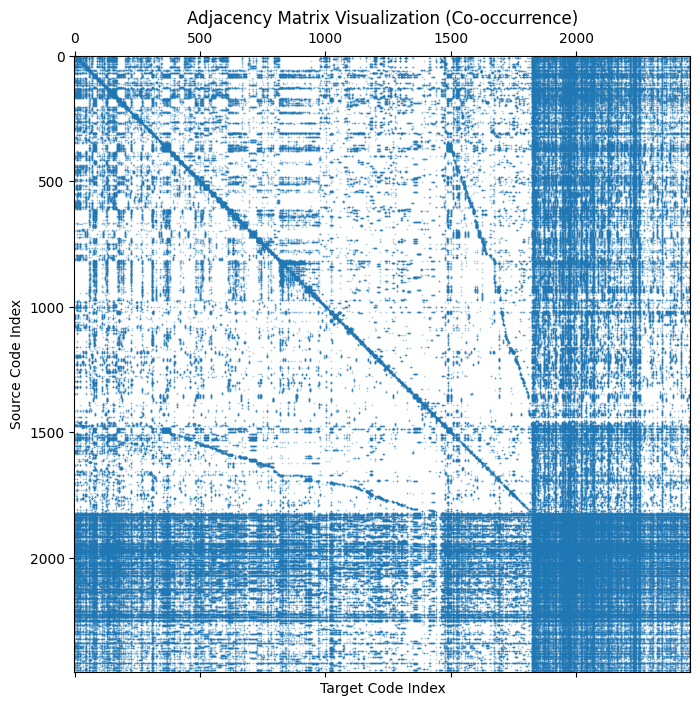

In [11]:
# 1. 희소 행렬 변환 (CSR 포맷이 연산에 빠름)
adj_matrix = adj_matrix.tocsr()

# 2. 정규화 (Normalization)
# 많이 등장한 코드는 연결도 많으므로, 등장 횟수로 나눠서 확률(Probability)로 바꿉니다.
# A -> B 확률: P(B|A) = Count(A, B) / Count(A)
row_sums = np.array(adj_matrix.sum(axis=1)).flatten()
# 0으로 나누는 것 방지
row_sums[row_sums == 0] = 1 

# 각 행을 합계로 나누기
d_inv = sparse.diags(1.0 / row_sums)
norm_adj = d_inv.dot(adj_matrix)

print(f"✅ 그래프 정규화 완료. (Max Probability: {norm_adj.max()})")

# 3. 시각화: 그래프가 얼마나 빽빽한가? (Sparsity)
plt.figure(figsize=(8, 8)) # 크기 살짝 키움
plt.spy(norm_adj, markersize=0.1)
plt.title("Adjacency Matrix Visualization (Co-occurrence)")
plt.xlabel("Target Code Index")
plt.ylabel("Source Code Index")

# 이미지 저장 (폴더가 없으면 생성)
import os
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/adjacency_matrix.png', dpi=150) # 해상도 높여서 저장
print("💾 그래프 시각화 이미지 저장 완료: ../images/adjacency_matrix.png")

plt.show()

In [13]:
# 1. 엣지 리스트 추출 (임계값 적용)
THRESHOLD = 0.05
rows, cols = norm_adj.nonzero()
values = np.array(norm_adj[rows, cols]).flatten()

mask = values > THRESHOLD
filtered_rows = rows[mask]
filtered_cols = cols[mask]
filtered_vals = values[mask]

# 2. 텐서 변환 (GNN 입력용) - 경고 해결 코드!
# 리스트([arr, arr]) 대신 np.array로 먼저 합칩니다.
edge_index_np = np.array([filtered_rows, filtered_cols])
edge_index = torch.tensor(edge_index_np, dtype=torch.long)
edge_weight = torch.tensor(filtered_vals, dtype=torch.float32)

print(f"=== 최종 그래프 통계 ===")
print(f"- 원본 엣지 수: {len(rows)}")
print(f"- 필터링 후 엣지 수: {len(filtered_rows)} (Threshold: {THRESHOLD})")
print(f"- Edge Index Shape: {edge_index.shape}") # [2, 4311] 확인

# 3. 저장
graph_data = {
    'edge_index': edge_index,
    'edge_weight': edge_weight,
    'num_nodes': total_vocab_size
}

save_path = '../data/graph_data.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(graph_data, f)
    
print(f"💾 그래프 데이터 저장 완료: {save_path}")

=== 최종 그래프 통계 ===
- 원본 엣지 수: 429070
- 필터링 후 엣지 수: 4311 (Threshold: 0.05)
- Edge Index Shape: torch.Size([2, 4311])
💾 그래프 데이터 저장 완료: ../data/graph_data.pkl
